In [31]:
import pandas as pd
import matplotlib.pyplot as plt
import urllib.request
import zipfile

# LOAD EROSION DATA
url = "https://coastal.er.usgs.gov/data-release/doi-P9XJRW5O/data/25_Year_KeyWest_Seafloor_Projection_MeanErosion.zip"
urllib.request.urlretrieve(url, "erosion_data.zip")

with zipfile.ZipFile("erosion_data.zip", "r") as z:
    csv_name = [f for f in z.namelist() if f.endswith('.csv')][0]
    with z.open(csv_name) as f:
        df = pd.read_csv(f)

# CLEAN DATA
df.columns = ['habitat', 'mean_erosion', 'max_elev', 'min_elev', 'mean_elev', 'sd']
df = df[df['habitat'] != 'Total study site']
df = df.dropna()

print(df.describe())

       mean_erosion   max_elev   min_elev  mean_elev         sd
count     14.000000  14.000000  14.000000  14.000000  14.000000
mean      -0.246621  -1.123157 -29.144075 -10.683352   4.128772
std        0.068747   3.531670  14.060011   6.796893   2.436400
min       -0.363000 -11.349999 -61.097698 -30.657887   0.415332
25%       -0.304225  -1.394950 -37.228575 -12.071276   3.085883
50%       -0.244550  -0.646154 -27.757641  -8.701116   3.682443
75%       -0.209700   0.185716 -15.997065  -6.659528   5.038282
max       -0.131100   5.096942 -13.016100  -4.884582   9.516240


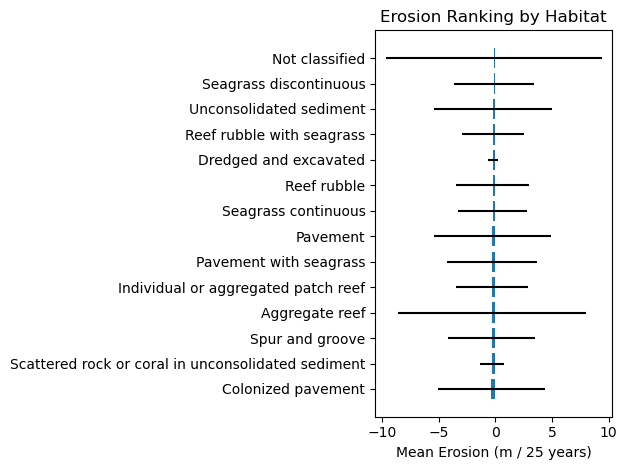

In [35]:
# VISUALIZATIONS

df_sorted = df.sort_values('mean_erosion')

plt.figure()
plt.barh(
    df_sorted['habitat'],
    df_sorted['mean_erosion'],
    xerr=df_sorted['sd']   # <-- fix here
)
plt.xlabel('Mean Erosion (m / 25 years)')
plt.title('Erosion Ranking by Habitat')
plt.tight_layout()
plt.show()

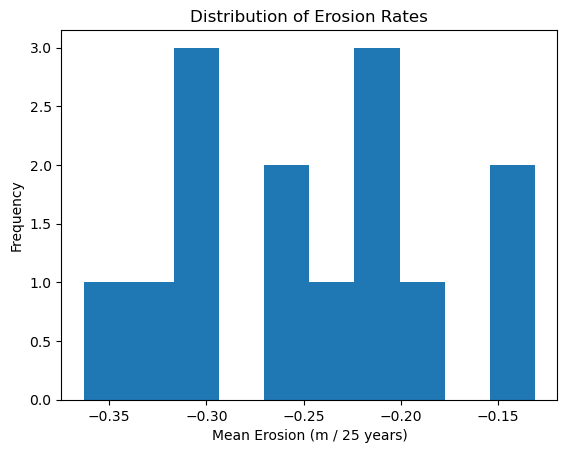

In [23]:
#Distribution histogram of erosion rates
plt.figure()
plt.hist(df['mean_erosion'], bins=10)
plt.xlabel('Mean Erosion (m / 25 years)')
plt.ylabel('Frequency')
plt.title('Distribution of Erosion Rates')
plt.show()